# Holten 2010 multi-tracer benchmark

This notebook accompanies the Holten example implemented in `examples/natural/holten/`.

Visser et al. (2013) studied groundwater age distributions in a public drinking-water well field near Holten, in the Netherlands, using several transient tracers. The scientific problem is practical and hydrogeologically important: long-screened production wells mix waters of different ages, so the goal is not to assign one apparent age to each well, but to understand the age mixture that controls present-day well vulnerability.

The paper shows in particular that a discrete `4-bin` model and a dispersion model with an old-water fraction both reproduce the observations reasonably well. It also highlights a strong contrast between shallower wells dominated by water younger than about `20` years and deeper wells containing a substantial fraction older than `60` years.

This notebook is intentionally didactic:
- it separates what comes directly from the paper from what is adapted for PyAge;
- it explains the tracer preparation choices before any inversion;
- it shows where the sampled values sit relative to physically meaningful reference curves;
- it runs the local article-style `4-bin` helper already implemented in this example;
- and it keeps visible the remaining gap between this local Holten helper and a future generic `n_bin_old` PyAge LPM.


In [ ]:
from pathlib import Path
import sys

from IPython.display import Image, display

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "pyage").exists():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.natural.holten.holten_case import build_context
from examples.natural.holten.holten_prepare import prepare_holten_inputs
from examples.natural.holten.holten_benchmark import (
    build_article_reference_figures,
    build_pre_model_figures,
    build_reference_comparison_figures,
    compare_with_reference_results,
)
from examples.natural.holten.holten_four_bin import run_local_4bin

ctx = build_context()
prepared = prepare_holten_inputs()
ctx


## 1. What comes directly from the paper

The following points are taken directly from the paper and from the local Holten source files:
- the case study concerns production wells sampled in April 2010 within the Holten well field;
- the core question is the age distribution of pumped water, not a single apparent age per well;
- the paper mainly relies on `3H/3He`, `85Kr`, and `39Ar`, with `4He` helping to diagnose the older component;
- short-screen monitoring wells around the well field are used to constrain vertical age stratification in the aquifer;
- the paper compares several model families, including discrete binned models and continuous distribution models with an old-water fraction;
- and it clearly separates younger, more vulnerable wells from deeper wells with a stronger old-water contribution.

In this repository, the V1 implementation draws its input data explicitly from:
- `sampling_data.txt` for production-well observations;
- `local_tritium.txt` for the `3H` input history;
- `freiburg_krypton.txt` for the `kr85` input history;
- `calibration_results.txt` for the published score table.

The wells `67-19`, `72-22`, and `85-33` were kept from the design phase because they provide a useful contrast between younger and older mixtures while remaining well documented for `3H`, `kr85`, and `39Ar`.


In [1]:
prepared.observed_aggregated


well_id,element,concentration,error,unit,date
67-19,3H,6.09,0.15,TU,2010.3014
67-19,kr85,39.70,1.50,dpm/ccKr,2010.3014
67-19,39Ar,1.04,0.08,%modern,2010.3014
72-22,3H,6.75,0.16,TU,2010.2986
72-22,kr85,35.90,1.30,dpm/ccKr,2010.2986
72-22,39Ar,0.93,0.06,%modern,2010.2986
85-33,3H,1.23,0.05,TU,2010.2986
85-33,kr85,2.70,0.20,dpm/ccKr,2010.2986
85-33,39Ar,0.51,0.08,%modern,2010.2986


## 2. What is adapted for PyAge and why

The goal is not to dilute Holten into the repository's generic tracer conventions, but to stay as close as possible to the paper while keeping the example executable today. The main adaptations are therefore explicit:
- `kr85` is kept in `dpm/ccKr` rather than converted to `pptv`, because this is the unit most directly connected to the Holten observations;
- `39Ar` is converted from `pMC` to a numerical fraction of modern, which matches the current internal PyAge convention;
- Holten tracers are prepared locally under `prepared_tracers/data_tracer/`, with no fallback to generic tracer definitions from the repository;
- a local article-style `4-bin` helper is implemented for this example, because the tracer-specific `old` end-member should not yet be forced into the generic PyAge LPM stack;
- and a local `uniform` LPM is still kept as a bootstrap launcher path so that the full workflow can already run end to end.

In other words, the example is now executable both as a preparation benchmark and as a first Holten-specific inversion benchmark. The future generic target remains a reusable `n_bin_old` PyAge LPM, not the disappearance of local Holten logic.


In [1]:
prepared.preparation_log


well_id,element,raw_value,raw_unit,converted_value,converted_unit,conversion_rule,source_field
67-19,3H,6.09,TU,6.09,TU,none,3H_TU
67-19,kr85,39.70,dpm/ccKr,39.70,dpm/ccKr,none,Kr85_dpm_ccKr
67-19,39Ar,104.00,pMC,1.04,%modern,pMC / 100,Ar39_pMC
72-22,3H,6.75,TU,6.75,TU,none,3H_TU
72-22,kr85,35.90,dpm/ccKr,35.90,dpm/ccKr,none,Kr85_dpm_ccKr
72-22,39Ar,93.00,pMC,0.93,%modern,pMC / 100,Ar39_pMC
85-33,3H,1.23,TU,1.23,TU,none,3H_TU
85-33,kr85,2.70,dpm/ccKr,2.70,dpm/ccKr,none,Kr85_dpm_ccKr
85-33,39Ar,51.00,pMC,0.51,%modern,pMC / 100,Ar39_pMC


## 3. Reference curves and pre-model reading

These figures are designed as a didactic step before calibration. They do not yet show a fitted age distribution. Instead, they answer a simpler question: *if we take each tracer seriously on its own, where do the 2010 sampled values sit relative to a physically meaningful reference curve?*

Each tracer figure has two complementary panels:
- the **top panel** shows a reference curve together with the 2010 sampled values;
- the **bottom panel** summarizes the concentration range of that same reference curve and places the sampled values inside that range.

The top panel should be read differently for the three tracers:
- for `3H`, the blue curve is the local tritium input history after radioactive decay has been applied up to the 2010 sampling year;
- for `kr85`, the blue curve is the local krypton-85 input history, converted to Holten units and then decayed to the 2010 sampling year;
- for `39Ar`, the blue curve is a theoretical decay curve referenced to the same 2010 sampling year, because the atmospheric modern reference is treated as constant in V1.

This matters because the observed well concentrations are not compared here to the raw historical input. They are compared to a **reference curve already expressed at the sampling date**. That is why the sampled values no longer look artificially tiny relative to the original bomb-pulse peaks.

The bottom panel is meant to be read as a compact diagnostic:
- the light bar shows the full concentration range of the reference curve;
- the darker bar shows the central part of that range (`q05-q95`);
- the vertical line marks the median of the reference curve;
- and the red points show where each well falls relative to that distribution.

A point near the right-hand side means that the sampled concentration is high relative to the reference curve. A point near the left-hand side means that the sample is low relative to that curve. In a mixed-age system, low values can reflect both radioactive decay and mixing with older water. This is exactly why these plots are only a pre-model reading: they are useful for intuition, but they do not replace the age-distribution model itself.


In [ ]:
pre_model_dir = ctx.paths.benchmark_dir / "pre_model"
generated = build_pre_model_figures(prepared, pre_model_dir)
generated


### Tracer-by-tracer view

The three figures below are embedded directly in the notebook.

Read them in this order:
- first, compare each red point with the blue reference curve in the top panel;
- then use the lower panel to see whether each sampled value lies in the low, central, or high part of that tracer's reference range;
- finally, compare the three tracers together: the useful signal does not come from one tracer alone, but from their combined consistency.


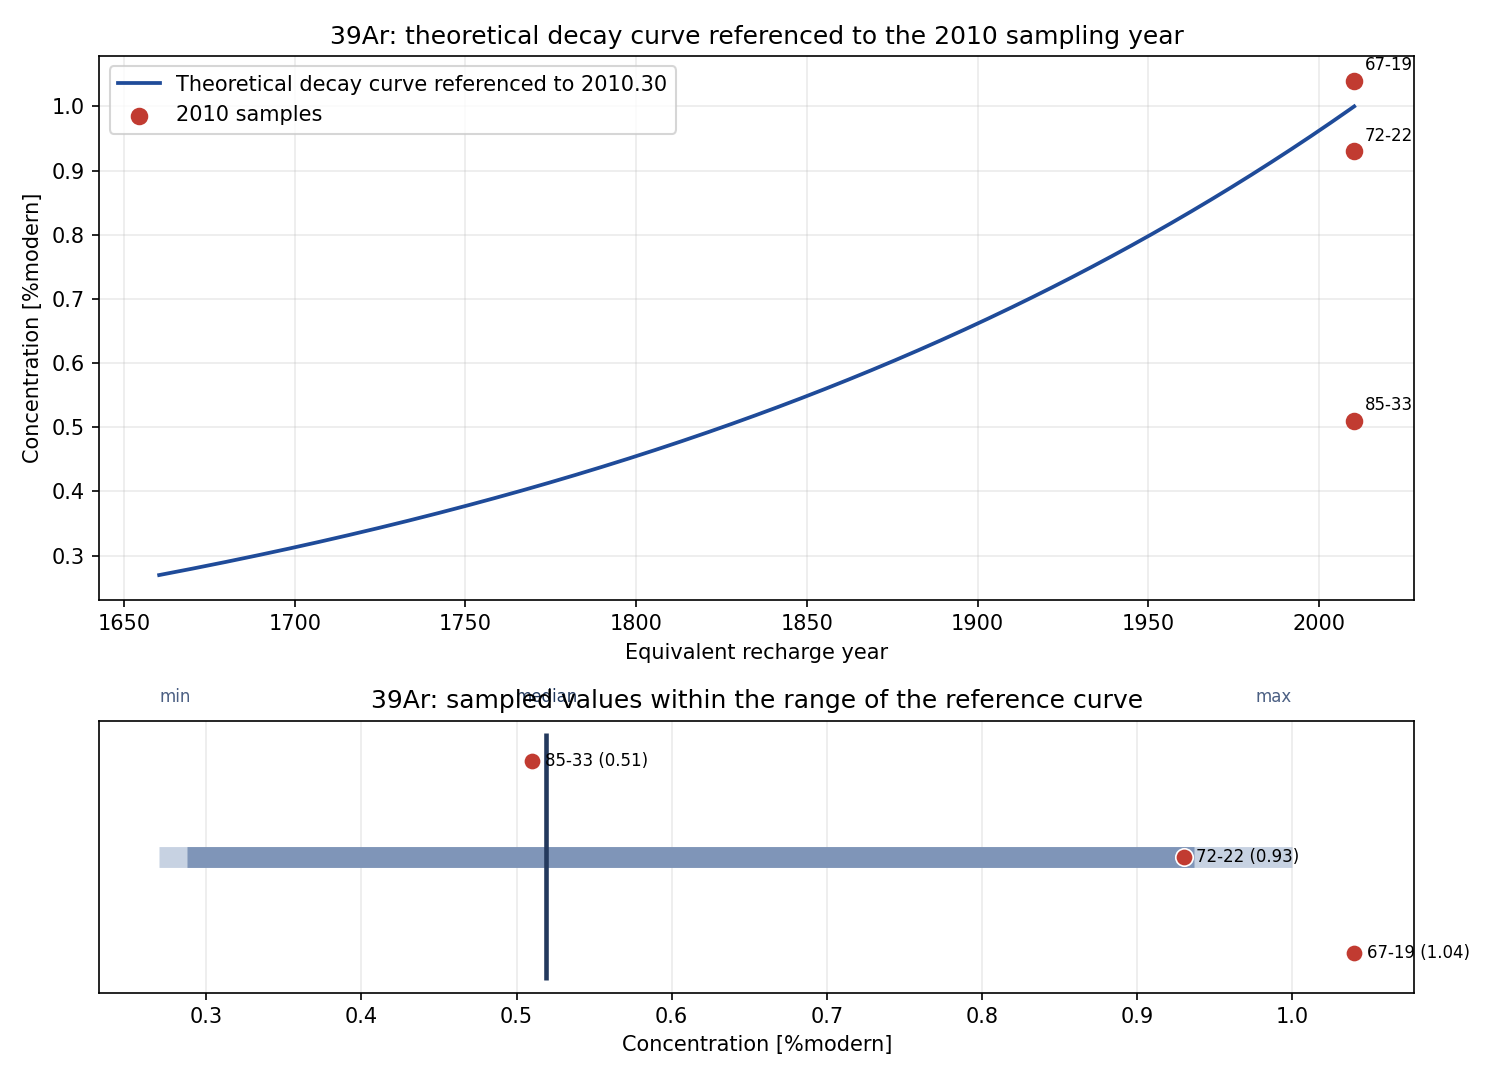

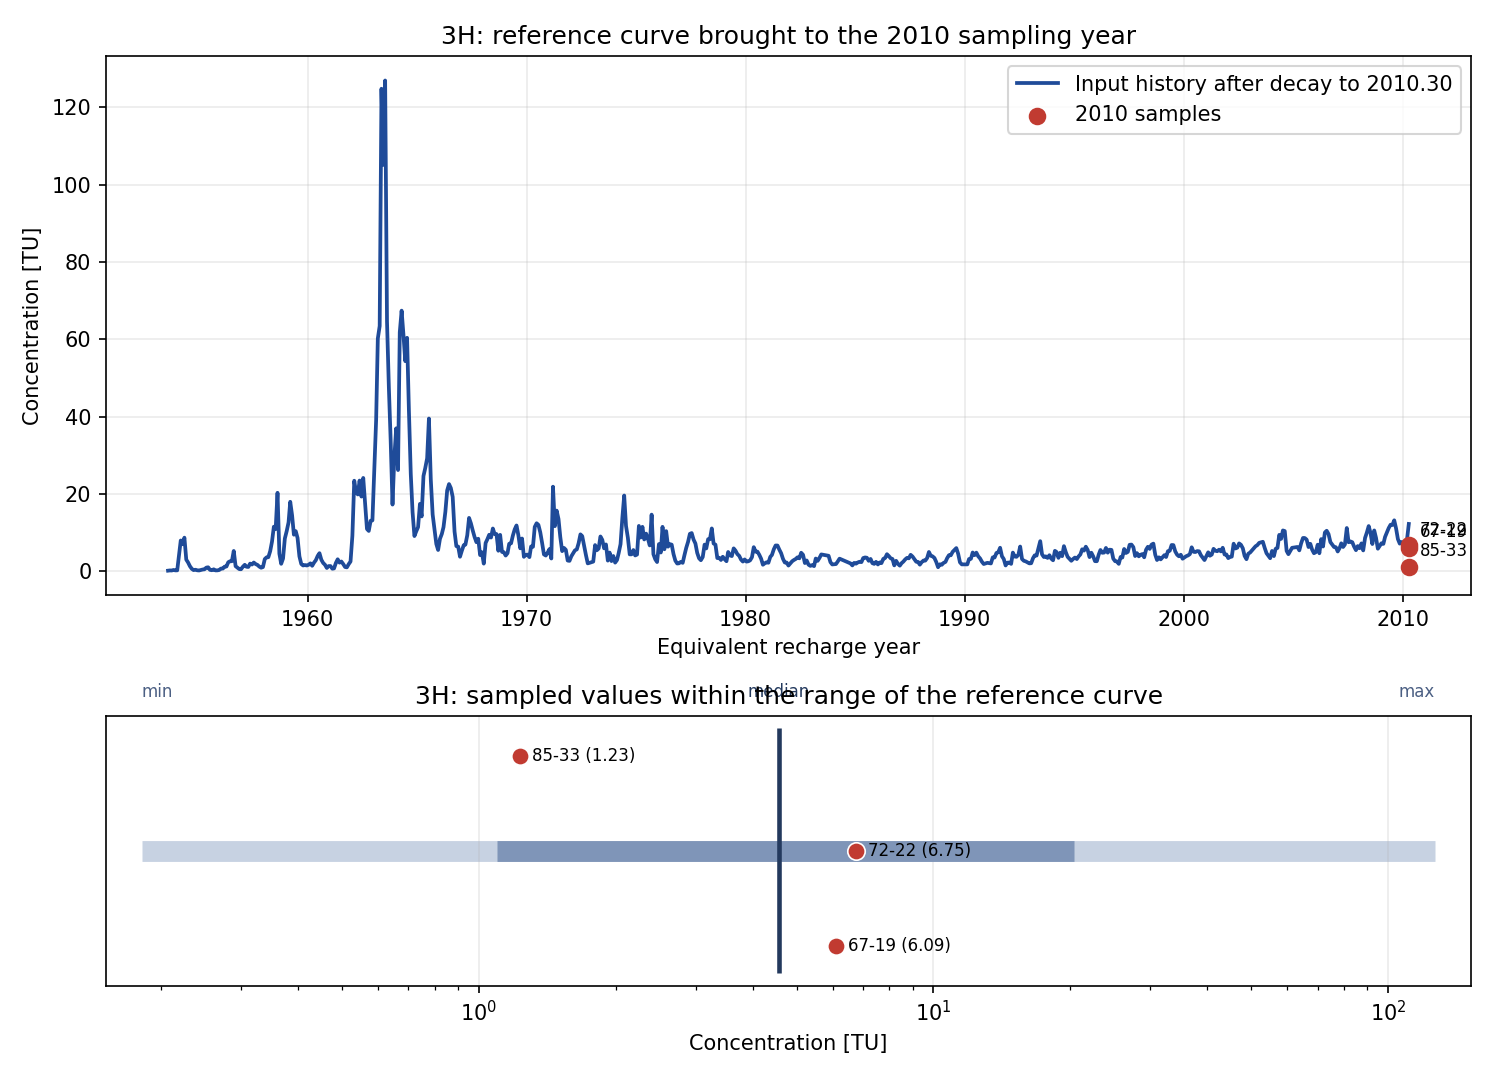

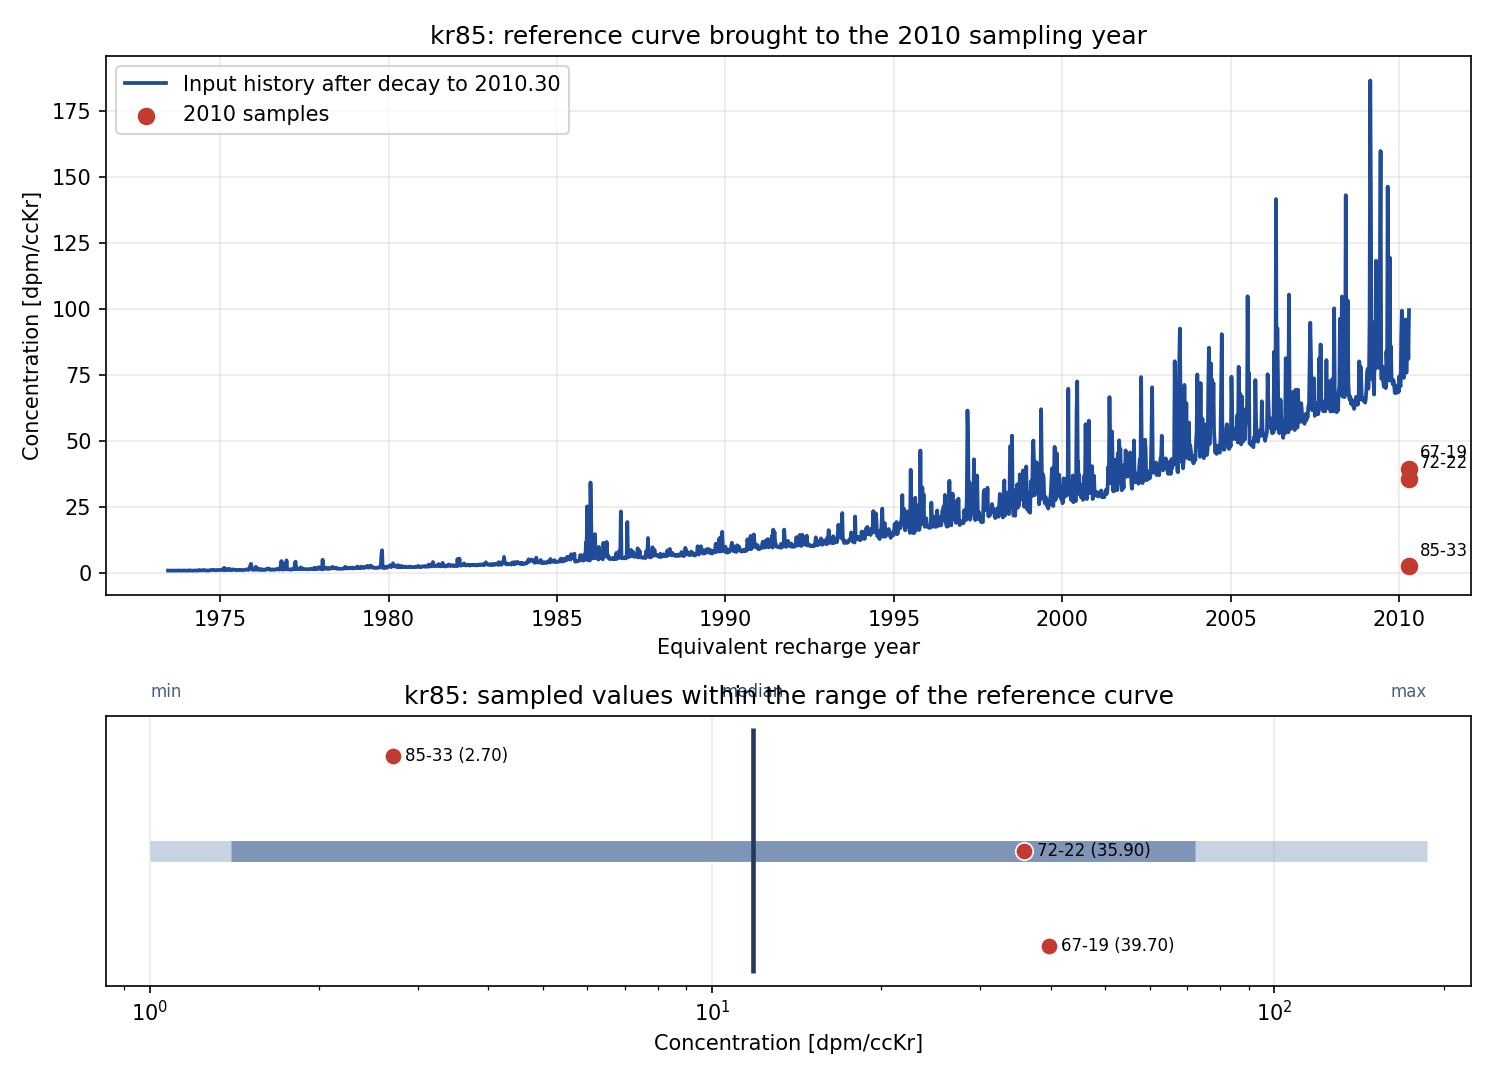

In [1]:
from IPython.display import Image, display

for path in sorted(pre_model_dir.glob("tracer_*_history_and_observations.png")):
    display(Image(filename=str(path), width=900))


### Well-by-well view

These panels transpose the same information well by well. They are useful for one specific question: *does one well systematically look younger or older across the three tracers at the same time?*

This is the first visual hint of an age mixture, before any formal fit is applied.


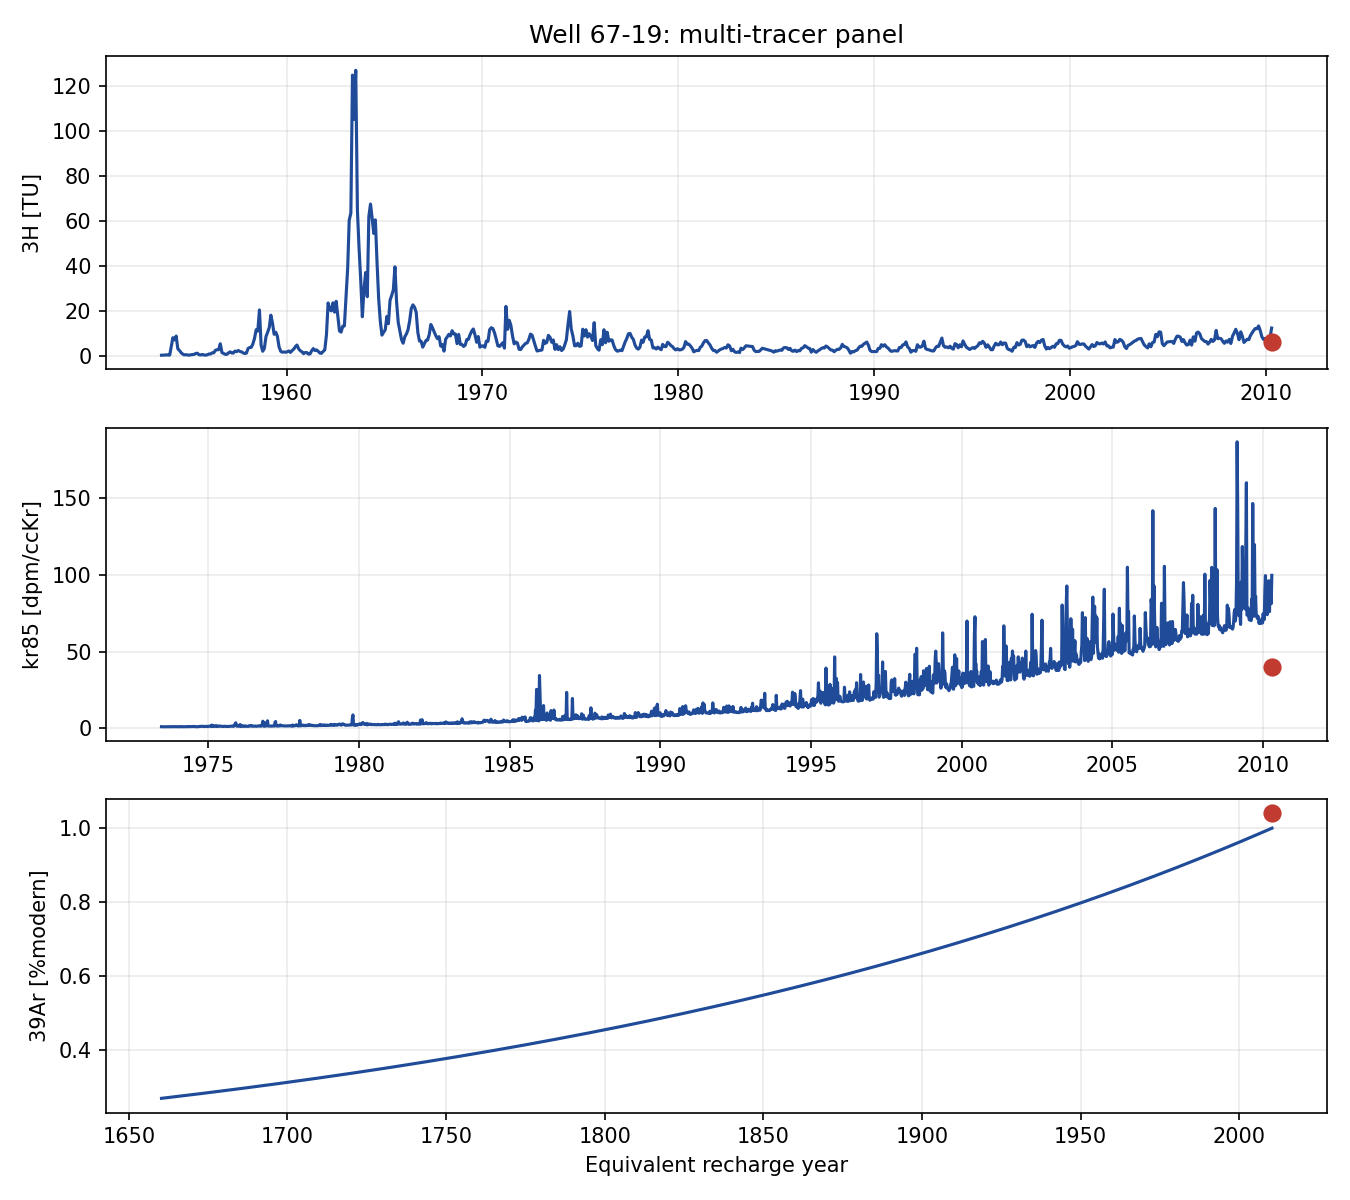

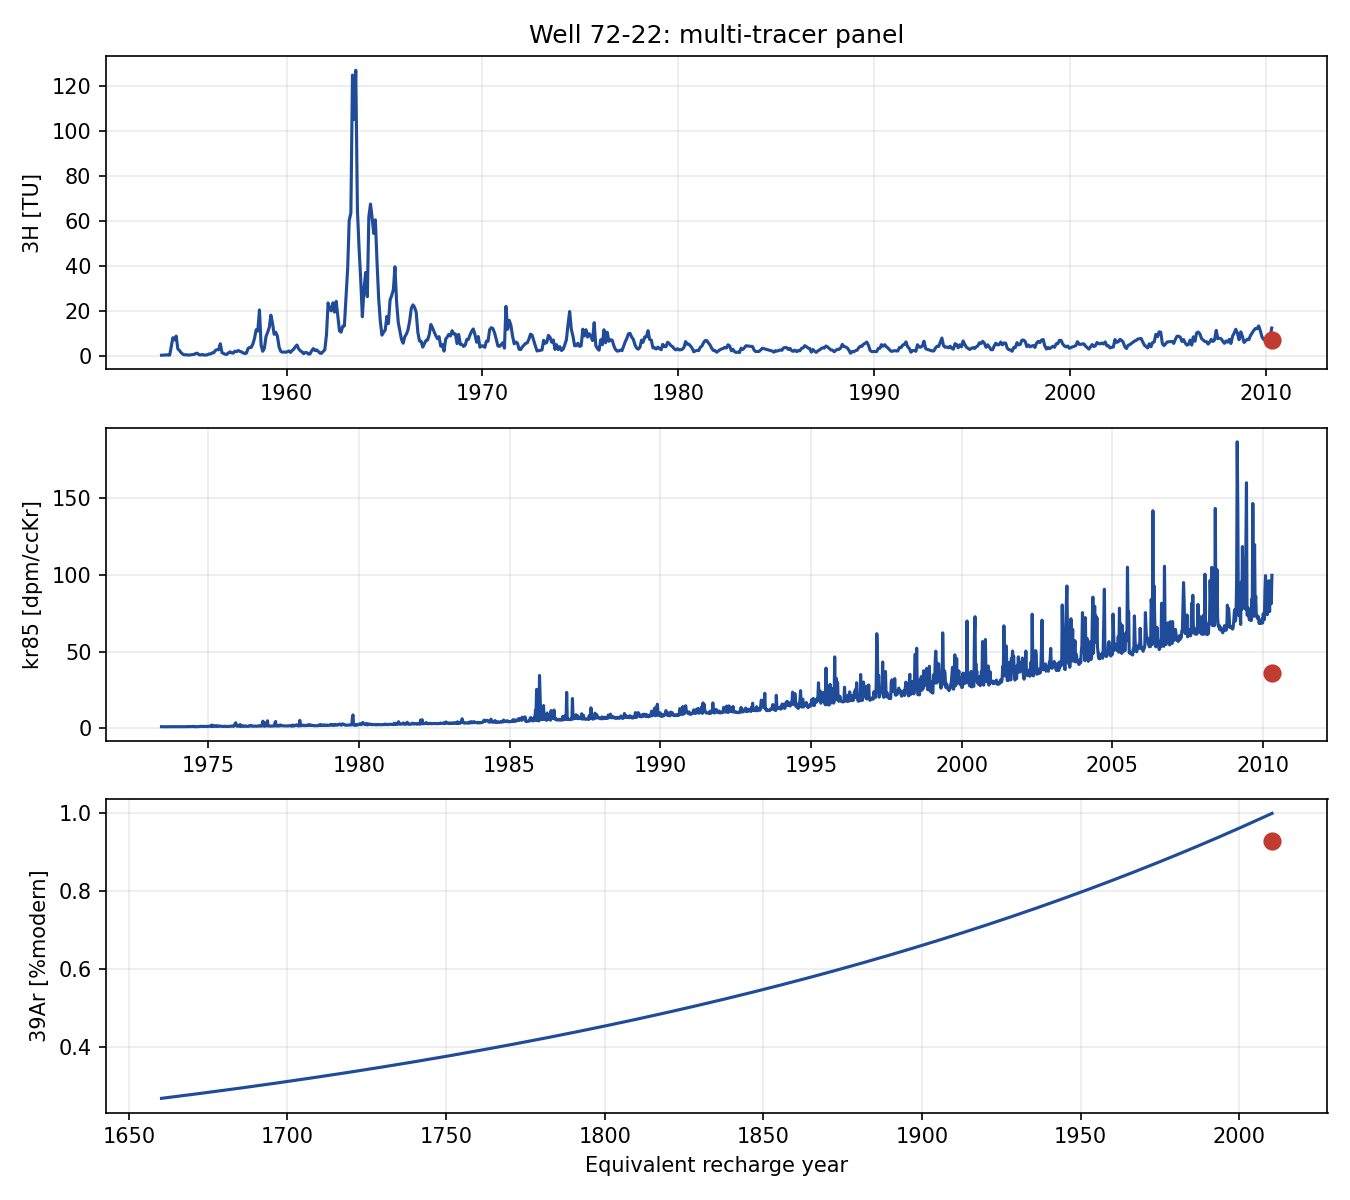

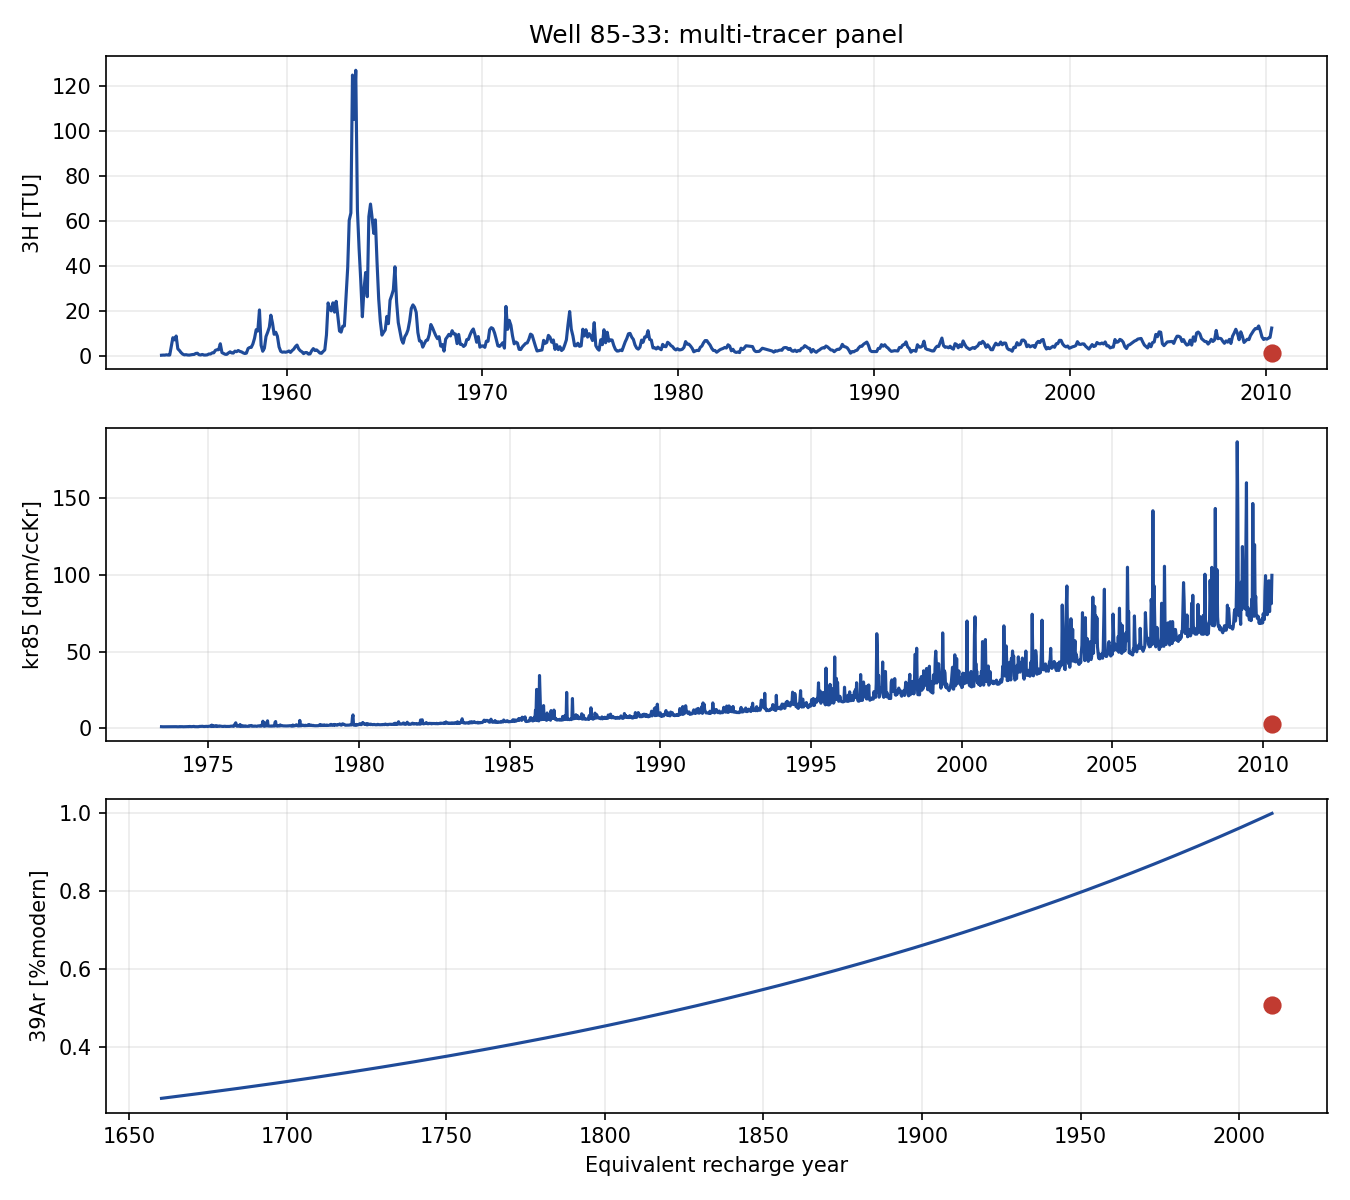

In [1]:
for path in sorted(pre_model_dir.glob("well_*_multi_tracer_panel.png")):
    display(Image(filename=str(path), width=860))


## 4. Figures from the paper used as anchors

The next four images are cropped directly from the local PDF of Visser et al. (2013). They are not meant to replace the repository figures. Instead, they act as anchors for interpretation.

Why these figures matter here:
- **Figure 4** reminds us that the `3H` story begins with the historical input pulse, not with a single measured well value;
- **Figure 8** shows why helium remains an interpretation topic rather than a V1 calibration target in this example;
- **Figure 9** is especially important because it links tracer-tracer behavior to the discrete `4-bin` logic adopted in the paper;
- **Figure 10** shows how the paper compares age-distribution model families, which is the benchmark logic reproduced here in a simplified form.


In [ ]:
article_dir = ctx.paths.benchmark_dir / "article_reference"
article_figures = build_article_reference_figures(ctx, article_dir)
article_figures


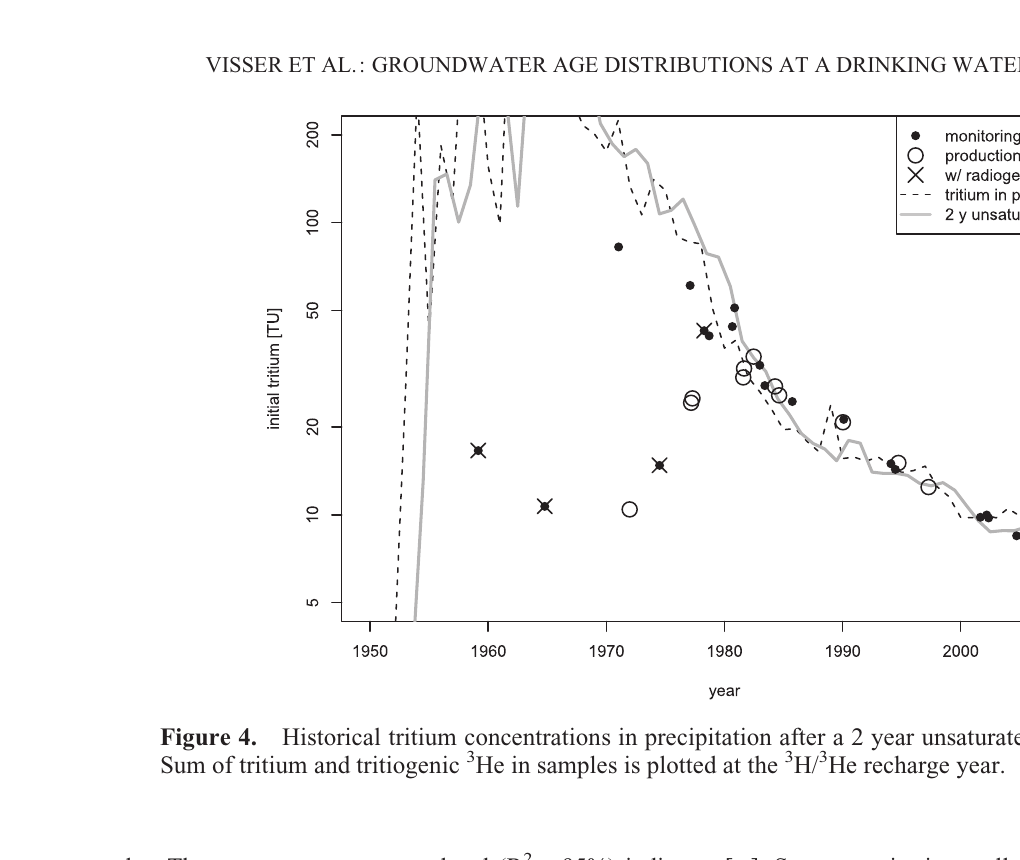

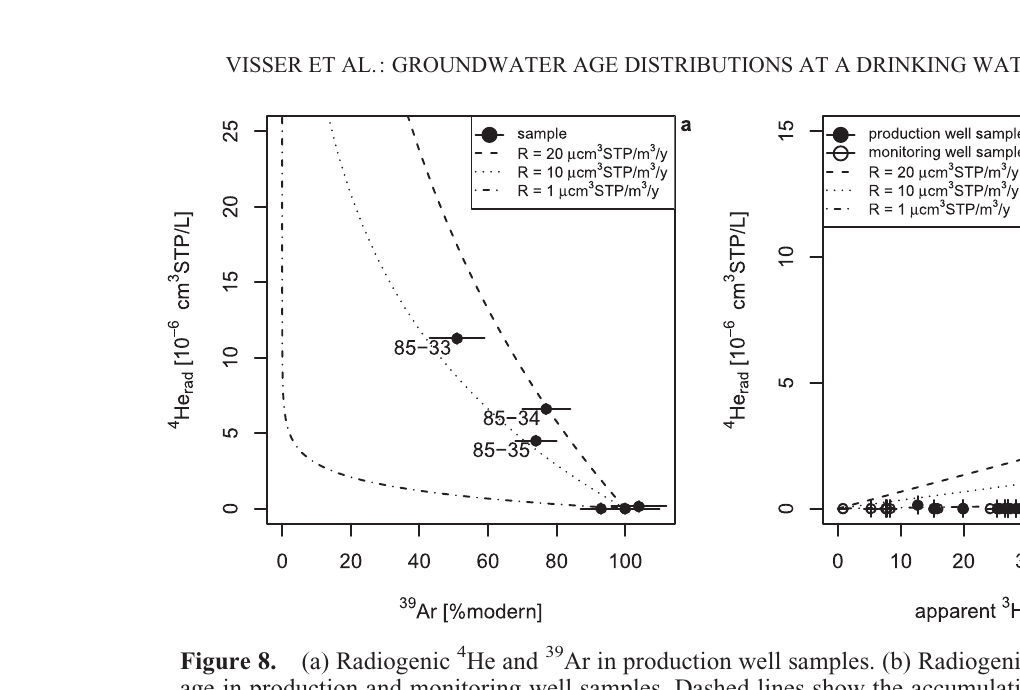

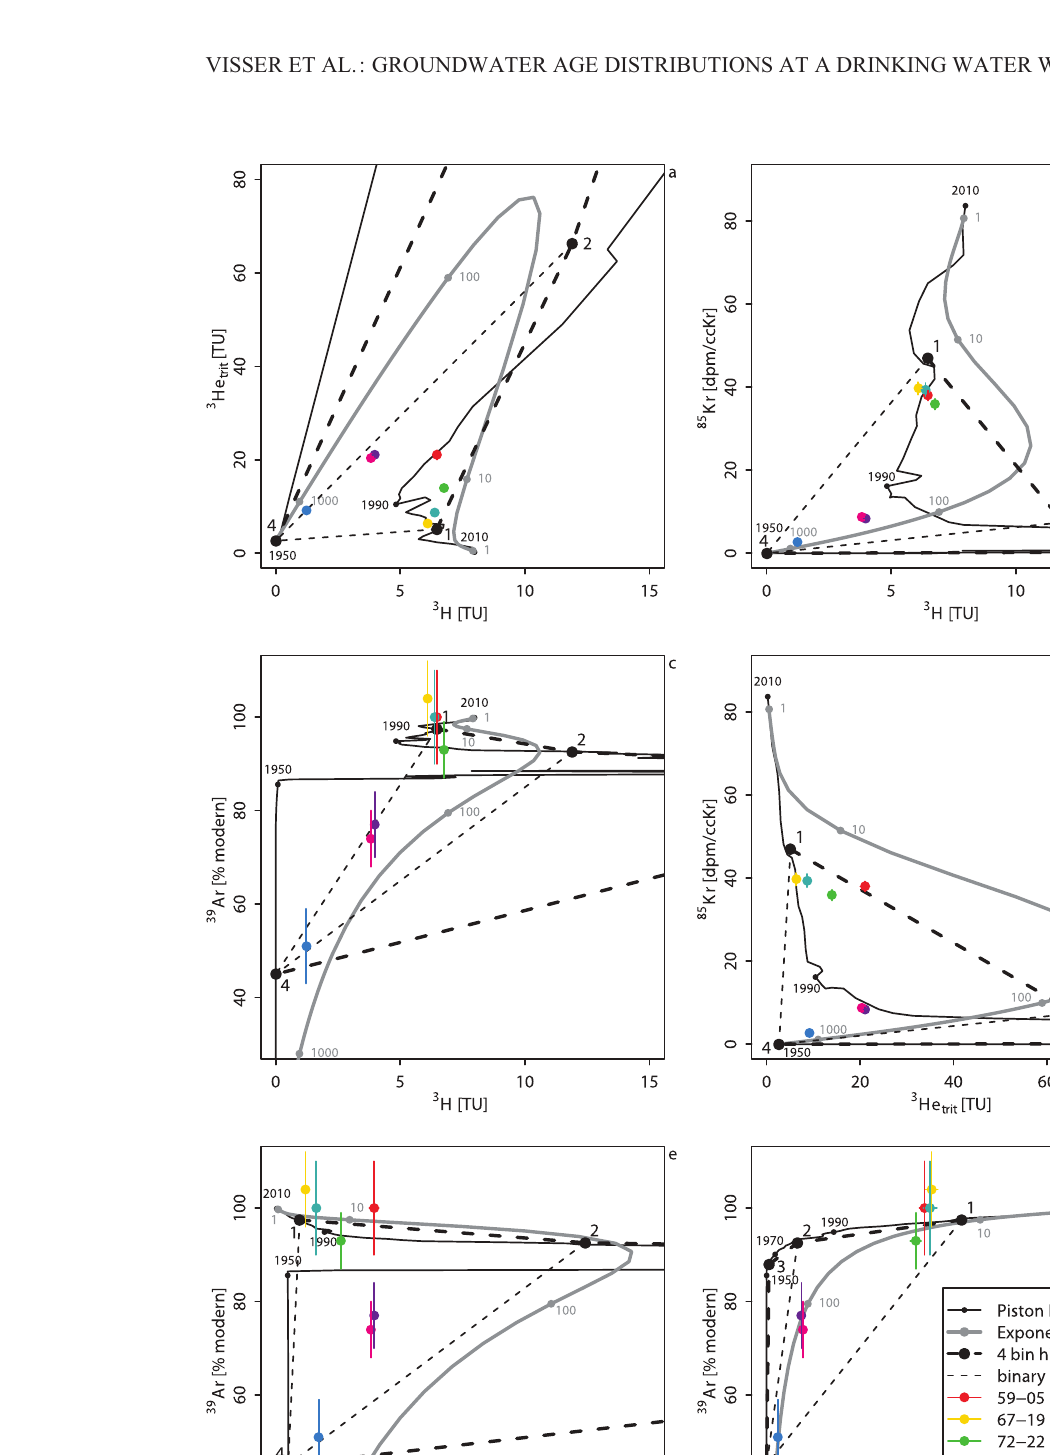

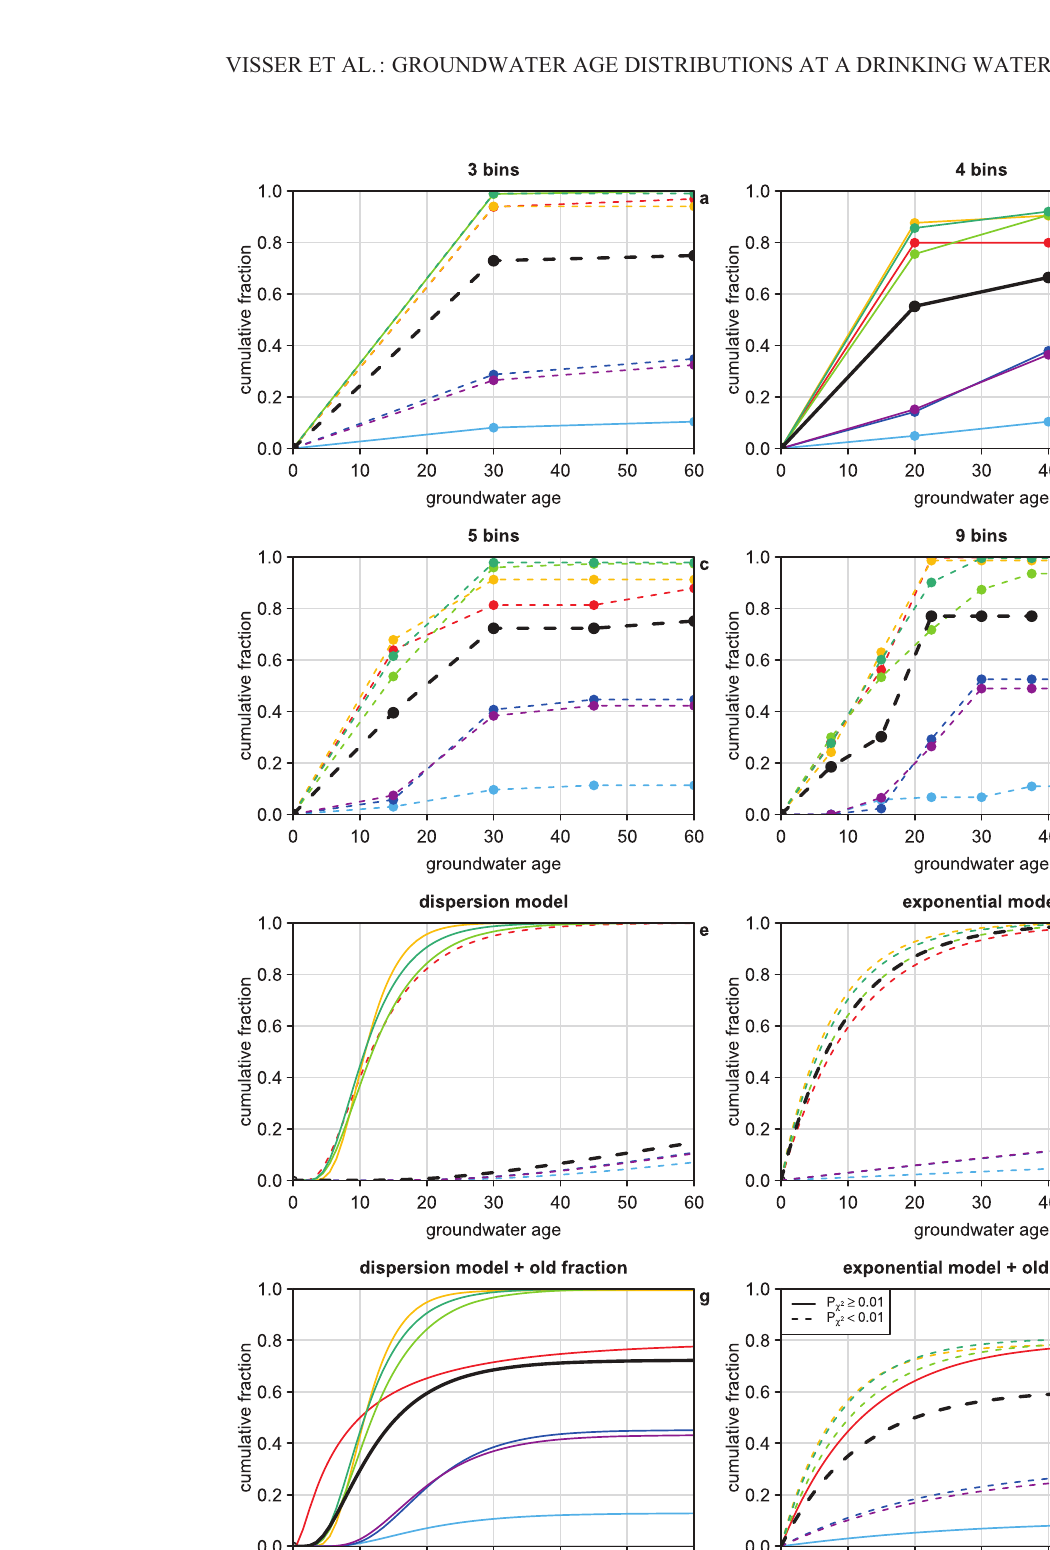

In [1]:
for name in ["figure_4.png", "figure_8.png", "figure_9.png", "figure_10.png"]:
    display(Image(filename=str(article_dir / name), width=920))


## 5. Local article-style 4-bin fit

This example now includes a Holten-specific local helper that fits four fractions:
- `0-20 years`
- `20-40 years`
- `40-60 years`
- `>60 years` (`old` fraction)

This is intentionally local to the Holten example for now. The reason is scientific rather than technical: the `old` component is tracer-specific in the way the paper is interpreted here, so it should not yet be pushed blindly into a generic repository-wide LPM.

The table below summarizes the current local fit for the three selected wells. Read it qualitatively first:
- a well dominated by `f_0_20` behaves like a mostly young mixture;
- a well dominated by `f_old` behaves like a mixture with a major older contribution;
- intermediate fractions should not be over-interpreted yet, because this remains a first benchmark helper rather than the final generic implementation.


In [1]:
four_bin_dir = ctx.paths.benchmark_dir / "four_bin"
local_4bin_endmembers, local_4bin_summary, local_4bin_fit, four_bin_paths = run_local_4bin(prepared, four_bin_dir)
local_4bin_summary.round(4)


well_id,f_0_20,f_20_40,f_40_60,f_old,chi2_local_4bin,rmse_local_4bin,weighted_rmse_local_4bin,mean_age_local_4bin,optimization_success,optimization_message
67-19,0.9454,0.0,0.0546,0.000,11.8579,2.1410,1.9881,12.1845,True,Optimization terminated successfully.
72-22,0.8387,0.0,0.1613,0.000,19.4836,2.3030,2.5484,16.4516,True,Optimization terminated successfully.
85-33,0.0709,0.0,0.0821,0.847,0.0089,0.0044,0.0546,267.3782,True,Optimization terminated successfully.


### 4-bin diagnostic figures

The first figure shows the estimated fractions for each well. The second figure compares observed and modeled concentrations tracer by tracer.

How to read them:
- if a well is almost entirely in the `0-20` bin, the fit is telling us that recent recharge dominates the signal;
- if the `>60` fraction dominates, the fit is telling us that a substantial old-water component is required to reproduce the observations;
- the observed-versus-modeled figure is the quick diagnostic of whether the fitted fractions are at least consistent with the three measured tracers together.


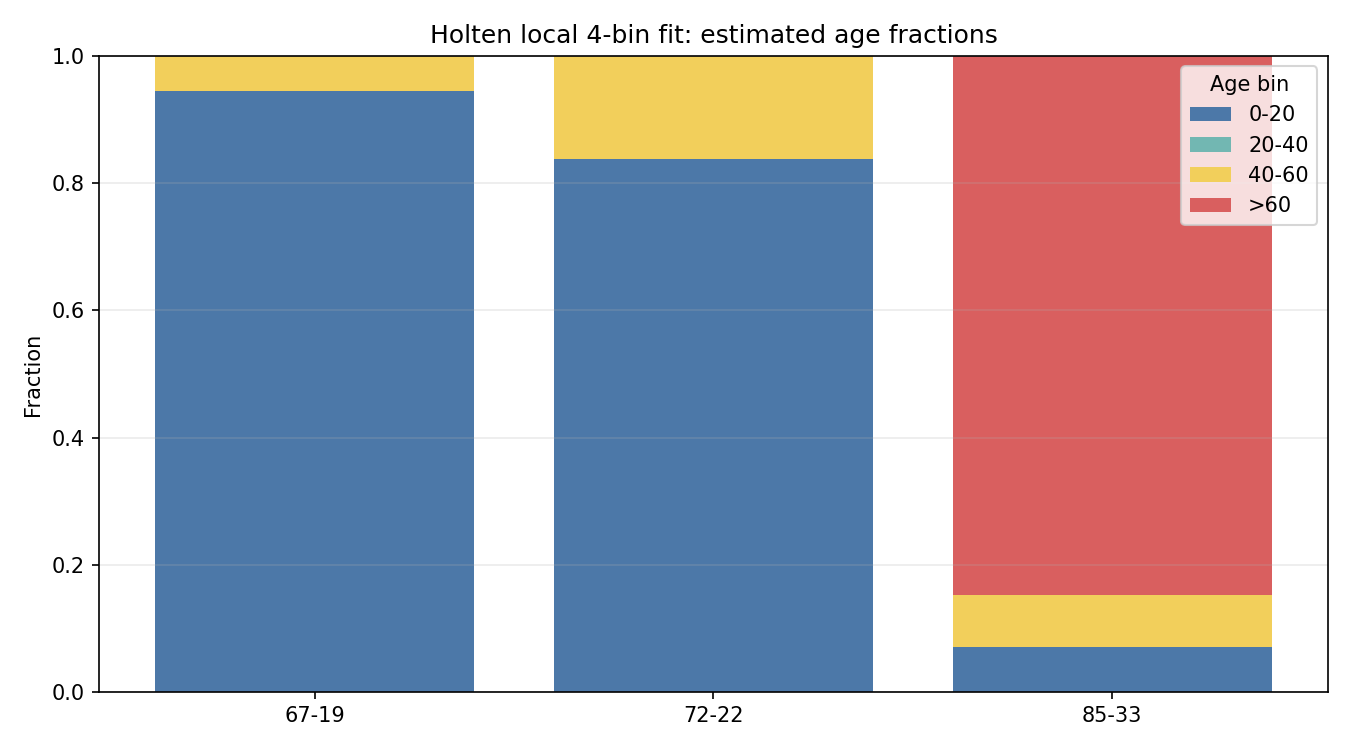

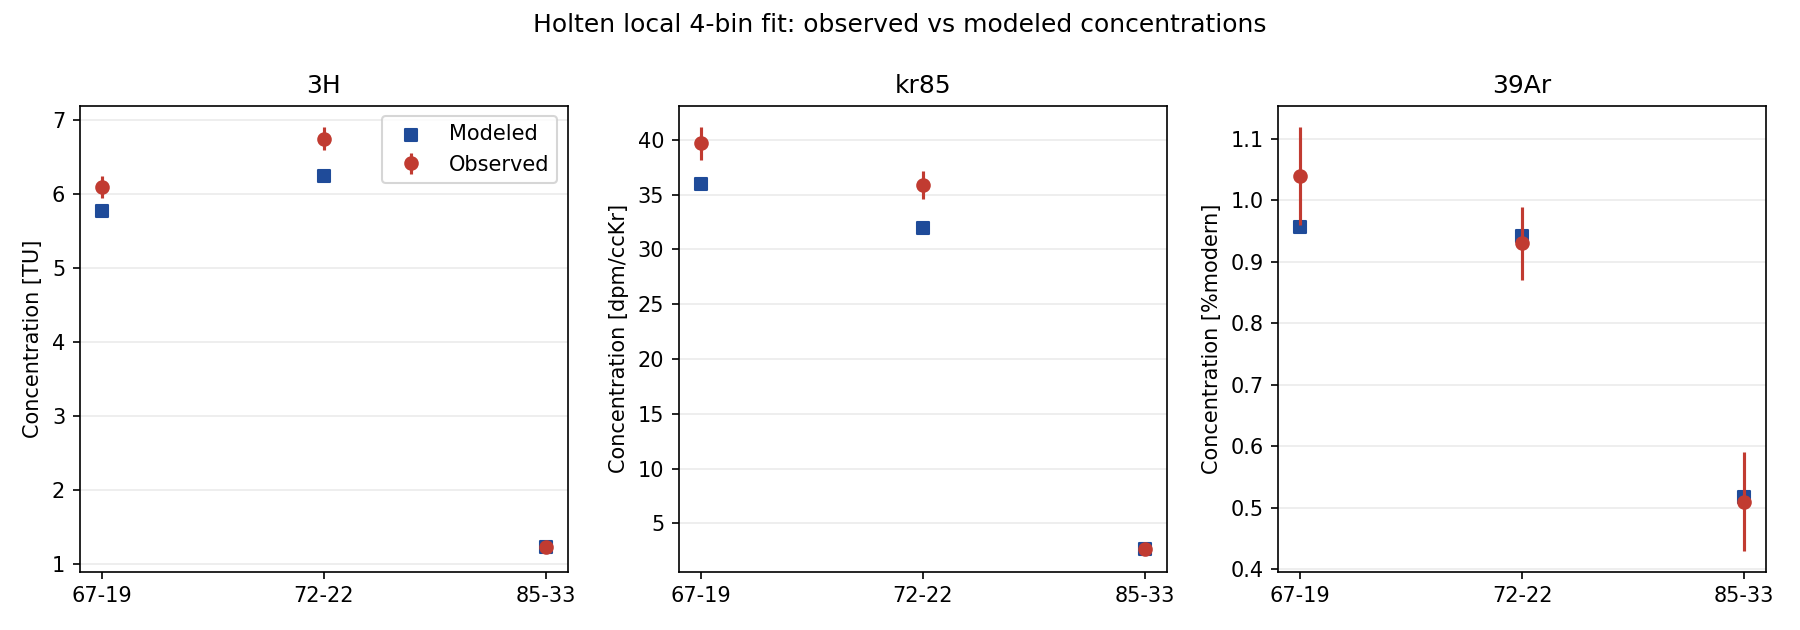

In [1]:
for name in ["holten_4bin_fractions.png", "holten_4bin_observed_vs_modeled.png"]:
    display(Image(filename=str(four_bin_dir / name), width=900))


## 6. Comparison with published benchmark results

The published table gives chi2-based scores for several model families. The goal here is not to claim numerical identity with the paper. The goal is more modest and more useful at this stage:
- reproduce the qualitative contrast between the selected wells;
- check whether the local `4-bin` helper behaves plausibly relative to the published `4-bin` benchmark;
- and keep visible which parts of the Holten workflow are already coherent before a generic `n_bin_old` implementation is introduced.


In [1]:
comparison = compare_with_reference_results(prepared, local_4bin_summary=local_4bin_summary)
comparison_figures = build_reference_comparison_figures(prepared, comparison, ctx.paths.benchmark_dir / "benchmark")
comparison.round(4)


well_id,reference_4bin_chi2,reference_4bin_pchi2,reference_best_model,local_4bin_chi2,local_4bin_rmse,local_4bin_mean_age,local_4bin_f_0_20,local_4bin_f_20_40,local_4bin_f_40_60,local_4bin_f_old,bootstrap_lpm,bootstrap_result_dir,bootstrap_rmse,calibration_available
67-19,3.9,5.0,DM_chi2,11.8579,2.1410,12.1845,0.9454,0.0,0.0546,0.000,uniform,C:\Users\dreuzy\results\PyAge\test_cases\holten_2010_67-19.txt,0.8620,True
72-22,0.6,45.0,9bin_chi2,19.4836,2.3030,16.4516,0.8387,0.0,0.1613,0.000,uniform,C:\Users\dreuzy\results\PyAge\test_cases\holten_2010_72-22.txt,0.4899,True
85-33,0.0,95.0,4bin_chi2,0.0089,0.0044,267.3782,0.0709,0.0,0.0821,0.847,uniform,C:\Users\dreuzy\results\PyAge\test_cases\holten_2010_85-33.txt,2.8511,True


The first figure below compares the published `4-bin` chi2 with the local Holten helper. The second figure summarizes the published scores of the main model families for the three selected wells.

This is the current benchmark bridge between the executable repository example and the original article.


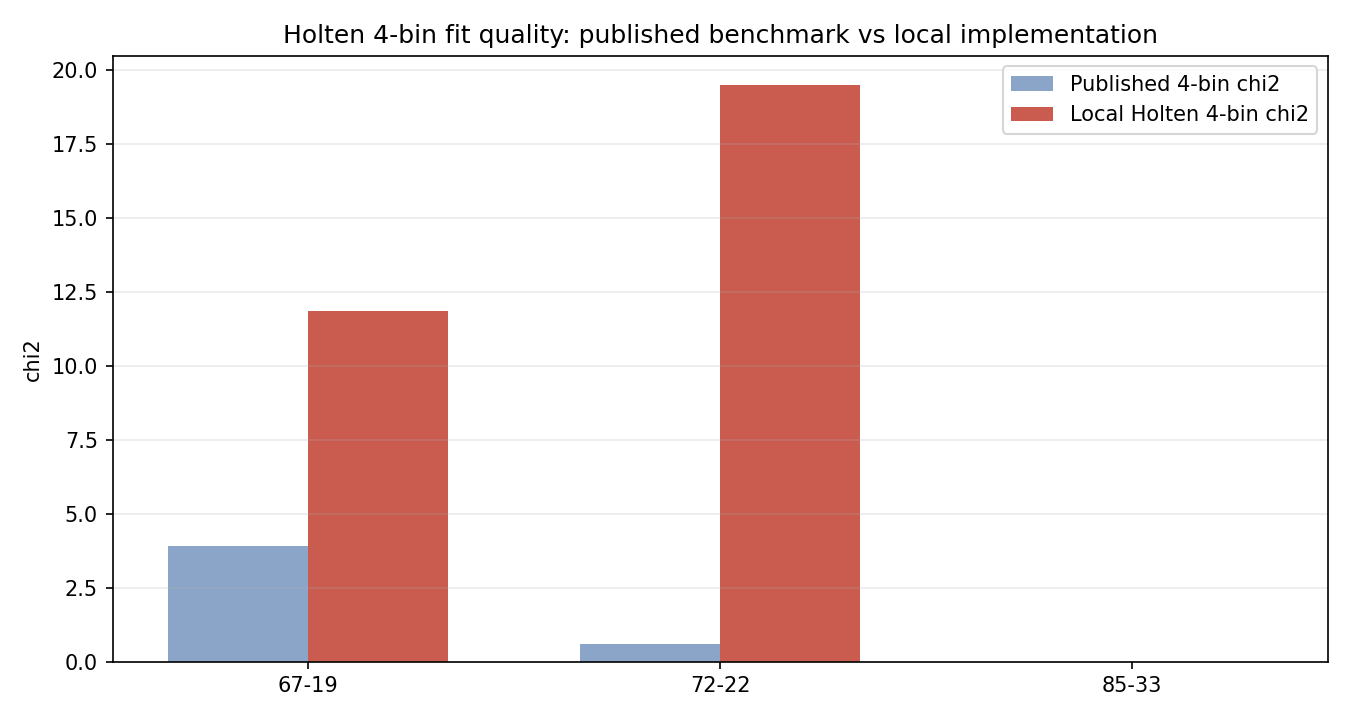

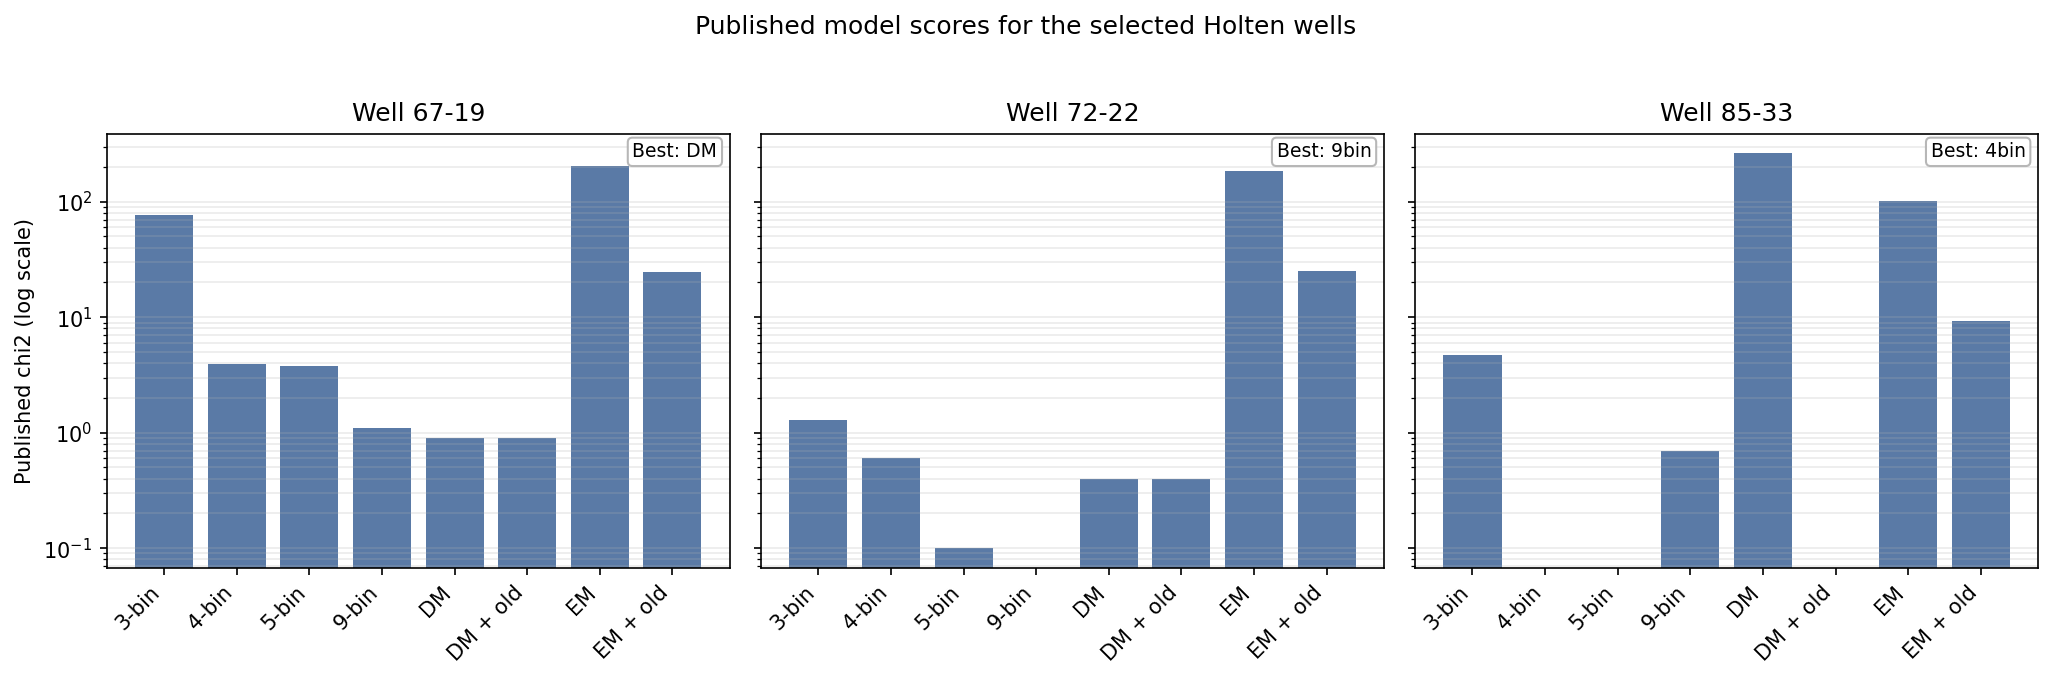

In [1]:
benchmark_plot_dir = ctx.paths.benchmark_dir / "benchmark"
for name in ["local_vs_reference_4bin_chi2.png", "published_model_scores.png"]:
    display(Image(filename=str(benchmark_plot_dir / name), width=980))
